Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
%%capture
!pip install watermark
!pip install torchinfo datasets

In [2]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.9.0+cu126



---
# Stacked Gated Recurrent Unit (Stacked GRU) Classifier

The network in this notebook is an implementation of a **Stacked Gated Recurrent Unit (Stacked GRU)** network **[1, 2]**. While a standard GRU is excellent for capturing temporal dependencies, a **Stacked GRU** introduces a hierarchical dimension. By stacking multiple layers, the model can learn different levels of abstraction: the lower layers capture local syntactic patterns (grammar and spelling), while the higher layers represent more complex, semantic concepts (context and intent).

<br><br>

**Network Architecture:**

In a Stacked GRU, the hidden state output of the first layer serves as the input sequence for the second layer. This "deep" recurrent structure allows the network to build a multi-layered representation of the text. This is particularly effective for complex datasets like **AG News**, where the relationship between words is not just sequential but hierarchical.


<br><br>

---

### **Key Concepts of the `Stacked GRU` Architecture:**

1. **Hierarchical Abstraction:** Much like a CNN has lower layers for edges and higher layers for shapes, a Stacked GRU uses Layer 1 to understand "how words are built" and Layer 2+ to understand "what the sentence means."
2. **Hidden State Propagation:** For each time step $t$, the output of the first layer $h_t^{(1)}$ is passed as the input $x_t^{(2)}$ to the second layer.
3. **Increased Capacity:** Stacking allows the model to learn more complex functions without necessarily increasing the `hidden_size` to an unmanageable degree, keeping the feature vector "dense."


<br><br>

---

### **Quick Comparison Table: Standard GRU vs. Stacked GRU**

| Feature | Standard GRU (Single Layer) | Stacked GRU (Multi-Layer) |
| --- | --- | --- |
| **Depth** | 1 Recurrent Layer | **2+ Recurrent Layers** |
| **Data Flow** | Input $\rightarrow$ Hidden $\rightarrow$ Output | **Input $\rightarrow$ Layer 1 $\rightarrow$ Layer 2 $\rightarrow$ Output** |
| **Abstraction** | Linear/Temporal | **Hierarchical/Deep** |
| **Parameter Count** | Base | **$N \times$ Base (Where $N$ is layers)** |
| **Risk** | Lower | **Higher (Potential Vanishing Gradients)** |
| **Best For** | Simple sequences / Small data | **Complex semantics / Large datasets** |

<br><br>

---

**REFERENCES:**

1. Pascanu, Razvan, et al. ["How to construct deep recurrent neural networks."](https://arxiv.org/abs/1312.6026) *arXiv preprint arXiv:1312.6026*, 2013. **(The "Deep RNN" Foundation)**
2. Cho, Kyunghyun, et al. ["Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation."](https://arxiv.org/abs/1406.1078) *arXiv preprint arXiv:1406.1078*, 2014. **(Original GRU Paper)**
3. Zhang, Xiang, Junbo Zhao, and Yann LeCun. ["Character-level Convolutional Networks for Text Classification."](https://arxiv.org/abs/1509.01626) *NeurIPS*, 2015.
4. Maas, Andrew L., et al. ["Learning Word Vectors for Sentiment Analysis."](https://ai.stanford.edu/~amaas/papers/wvSent_acl2011.pdf) *ACL*, 2011. **(IMDB Dataset Source)**
5. Google. (2026). ["Gemini 3 Flash"](https://gemini.google.com/) [Large language model]. Google AI

---


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, DatasetDict
from collections import Counter


# from torch.cuda.amp import GradScaler, autocast
from torch.amp import GradScaler, autocast
from torchinfo import summary

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random
import re

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [4]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

---
# 0. Model Hyperparameters
---

In [5]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_EPOCHS = 10        # News topics usually converge faster than char-level text
NUM_CLASSES = 4        # [World, Sports, Business, Sci/Tech]

# Vocabulary & Architecture
VOCABULARY_SIZE = 20000 
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
DROPOUT_P = 0.5        # Crucial for Stacked architectures to prevent overfitting

# Sequence Constraints
MAX_LEN = 100          # AG News sentences are shorter than Wikipedia/Shakespeare chunks
# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


---
# 1. Data Preparation & Loading

---

In [6]:
# 1. Load Dataset (IMDB)
raw_datasets = load_dataset("ag_news")


# 2. Split 10% of 'train' to create a 'validation' set (seed for reproducibility)
train_val_split = raw_datasets["train"].train_test_split(test_size=0.1, seed=RANDOM_SEED)

ds_splits = DatasetDict({
    'train': train_val_split['train'],
    'validation': train_val_split['test'], # The 10% we just carved out
    'test': raw_datasets['test']
})

print(ds_splits)

# 2. Build Vocabulary (From Scratch Logic)
tokenizer = lambda text: re.findall(r'\w+', text.lower())
word_counts = Counter()

# Important: We only iterate over ds_splits['train']
for text in ds_splits['train']['text']:
    word_counts.update(tokenizer(text))

# Filter rare words and create mapping: : <PAD>=0, <UNK>=1, then top 20k words
vocab = {word: i + 2 for i, (word, count) in enumerate(word_counts.most_common(VOCABULARY_SIZE))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

print(f"Vocab size: {len(vocab)}")

# 3. Custom Dataset Class
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_split):
        self.data = dataset_split

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Return raw text and label. Let collate_fn handle the rest.
        item = self.data[idx]
        return item['text'], item['label']

# 4. Robust Text Pipeline
def text_pipeline(text, max_len=128):
    tokens = tokenizer(text)
    # Use .get(t, 1) because 1 is your <UNK> index
    return [vocab.get(t, 1) for t in tokens][:max_len]

# 5. Robust Collate Batch
def collate_batch(batch):
    label_list, text_list, lengths = [], [], []

    for _text, _label in batch:
        # 1. Labels: Use LONG for AG News (Multi-class)
        label_list.append(_label)

        # 2. Numericalize and Truncate
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        text_list.append(processed_text)
        lengths.append(processed_text.size(0))

    # 3. Padding logic
    # We use <PAD> index 0. We use vocab.get just in case names change.
    pad_idx = vocab.get('<PAD>', 0)

    # This dynamically pads to the longest sequence in THIS batch (more efficient)
    text_list_padded = pad_sequence(text_list, batch_first=True, padding_value=pad_idx)
    label_tensor = torch.tensor(label_list, dtype=torch.long)
    length_tensor = torch.tensor(lengths, dtype=torch.int64)

    return text_list_padded.to(DEVICE), label_tensor.to(DEVICE), length_tensor.to(DEVICE)

# 6. Initialize DataLoaders
train_ds = TextDataset(ds_splits['train'])
val_ds   = TextDataset(ds_splits['validation'])
test_ds  = TextDataset(ds_splits['test'])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 108000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 12000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Vocab size: 20002


---
# 2. Model Creation

---


In [7]:
class GRUCellFromScratch(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        # We need weights for 3 operations:
        # Update gate (z), Reset gate (r), and Candidate hidden state (h_tilde)
        self.gate_weights = nn.Linear(input_size + hidden_size, 2 * hidden_size)
        self.candidate_weights = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev):
        # x: [batch, input_size]
        # h_prev: [batch, hidden_size]

        # 1. Calculate Update (z) and Reset (r) gates
        combined = torch.cat((x, h_prev), dim=1)
        gates = torch.sigmoid(self.gate_weights(combined))
        z_gate, r_gate = gates.chunk(2, dim=1)

        # 2. Calculate Candidate Hidden State (h_tilde)
        # We use the Reset gate to "mask" the previous hidden state
        combined_candidate = torch.cat((x, r_gate * h_prev), dim=1)
        h_tilde = torch.tanh(self.candidate_weights(combined_candidate))

        # 3. Final Hidden State update
        # This is a linear interpolation between past and candidate
        h_curr = (1 - z_gate) * h_prev + z_gate * h_tilde

        return h_curr

In [8]:
class StackedGRUFromScratch(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, output_size, dropout_p=0.5):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        self.gru1 = GRUCellFromScratch(embed_dim, hidden_size)
        self.gru2 = GRUCellFromScratch(hidden_size, hidden_size)
        
        self.dropout = nn.Dropout(dropout_p)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, lengths):
        batch_size, seq_len = x.shape
        x = self.embedding(x)
        
        h1 = torch.zeros(batch_size, self.hidden_size).to(x.device)
        h2 = torch.zeros(batch_size, self.hidden_size).to(x.device)

        # --- LAYER 1 ---
        l1_all_h = []
        for t in range(seq_len):
            h1_next = self.gru1(x[:, t, :], h1)
            
            # MASK 1: Only update if t < actual length
            mask = (t < lengths).float().unsqueeze(1)
            h1 = (mask * h1_next) + ((1 - mask) * h1)
            
            l1_all_h.append(h1.unsqueeze(1))
        
        l1_all_h = torch.cat(l1_all_h, dim=1)
        
        # --- VERTICAL DROPOUT ---
        l1_all_h = self.dropout(l1_all_h)

        # --- LAYER 2 ---
        l2_all_h = []
        for t in range(seq_len):
            # Input to L2 is the masked/dropped output of L1
            h2_next = self.gru2(l1_all_h[:, t, :], h2)
            
            # MASK 2: Freeze h2 as well once padding starts
            mask = (t < lengths).float().unsqueeze(1)
            h2 = (mask * h2_next) + ((1 - mask) * h2)
            
            l2_all_h.append(h2.unsqueeze(1))
            
        l2_all_h = torch.cat(l2_all_h, dim=1)

        # --- FINAL SELECTION ---
        idx = (lengths - 1).view(-1, 1, 1).expand(batch_size, 1, self.hidden_size)
        last_h = l2_all_h.gather(1, idx).squeeze(1)

        return self.fc(last_h)

In [9]:
def get_robust_maxlen(dataset, tokenizer, p=95, absolute_max=512):
    # 1. Get the statistical length
    lengths = [len(tokenizer(ex[0])) for ex in dataset]
    p_length = np.percentile(lengths, p)

    # 2. Find the next power of 2
    # math.log2 gives the exponent, ceil rounds up, 2** raises it back
    # We use max(16, ...) to ensure we don't get a tiny length like 4 or 8
    robust_len = 2 ** math.ceil(math.log2(max(16, p_length)))

    # 3. Cap at absolute_max
    final_len = min(robust_len, absolute_max)

    print(f"{p}th Percentile: {p_length:.2f}")
    print(f"Nearest Power of 2: {robust_len}")
    print(f"Final Robust MAX_LEN: {final_len}")

    return final_len

# Usage
__MAX_LEN = get_robust_maxlen(train_ds, tokenizer, p=95)

95th Percentile: 58.00
Nearest Power of 2: 64
Final Robust MAX_LEN: 64


In [11]:
VOCAB_SIZE = len(vocab)
MAX_LEN 

100

In [12]:
# --- Configuration Switch ---
DATASET_NAME = "ag-news"

if DATASET_NAME == "IMDB":
    IS_BINARY = True
    NUM_CLASSES = 1
    # criterion = nn.BCEWithLogitsLoss()
else:
    IS_BINARY = False
    NUM_CLASSES = 4 # AG News has 4 classes
    # criterion = nn.CrossEntropyLoss()

In [14]:
set_all_seeds(RANDOM_SEED)
model = StackedGRUFromScratch(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_DIM,
    output_size=NUM_CLASSES,
    dropout_p=0.5
).to(DEVICE)

summary(model,
        input_data=(torch.zeros((BATCH_SIZE, MAX_LEN), dtype=torch.long).to(DEVICE),
                    torch.ones((BATCH_SIZE,), dtype=torch.long).to(DEVICE) * MAX_LEN),
        col_names=["input_size", "output_size", "num_params", "mult_adds"],
        device=DEVICE)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
StackedGRUFromScratch                    [128, 100]                [128, 4]                  --                        --
├─Embedding: 1-1                         [128, 100]                [128, 100, 128]           2,560,256                 327,712,768
├─GRUCellFromScratch: 1-2                [128, 128]                [128, 256]                --                        --
│    └─Linear: 2-1                       [128, 384]                [128, 512]                197,120                   25,231,360
│    └─Linear: 2-2                       [128, 384]                [128, 256]                98,560                    12,615,680
├─GRUCellFromScratch: 1-3                [128, 128]                [128, 256]                (recursive)               --
│    └─Linear: 2-3                       [128, 384]                [128, 512]                (recursive)          

---
# 3. Model Training, Testing & Evaluation

---

In [15]:
def calculate_accuracy(loader, model, device, is_binary=True):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for inputs, labels, lengths in loader:
            inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)
            logits = model(inputs, lengths)

            if is_binary:
                predicted = (torch.sigmoid(logits.view(-1)) > 0.5).long()
            else:
                _, predicted = torch.max(logits.data, 1)

            total += labels.size(0)
            correct += (predicted == labels.long()).sum().item()

    return 100 * correct / total

In [16]:
IS_BINARY, NUM_CLASSES

(False, 4)

In [17]:
# 1. Update Optimizer and Scheduler
# Binary uses BCEWithLogitsLoss; Multi-class uses CrossEntropy
criterion = nn.BCEWithLogitsLoss() if IS_BINARY else nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Robust Scheduler: Cosine Annealing
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [18]:
start_time = time.time()
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lrs': []}

print(f"Starting training on {DEVICE}...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    # 1. Training Phase
    for i, (inputs, labels, lengths) in enumerate(train_loader):
        inputs, labels, lengths = inputs.to(DEVICE), labels.to(DEVICE), lengths.to(DEVICE)

        optimizer.zero_grad()

        # Forward pass (passing lengths for masking logic)
        logits = model(inputs, lengths)

        if IS_BINARY:
            loss = criterion(logits.squeeze(), labels.float())
        else:
            loss = criterion(logits, labels.long())

        loss.backward()

        # --- ROBUST RNN FIX: Gradient Clipping ---
        # Prevents gradients from "exploding" during the backprop through time (BPTT)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    # 2. Metrics Calculation
    # Note: Using the updated calculate_accuracy that handles (inputs, lengths)
    train_loss = running_loss / len(train_ds)
    train_acc = calculate_accuracy(train_loader, model, DEVICE, is_binary=IS_BINARY)

    # 3. Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels, lengths in val_loader:
            inputs, labels, lengths = inputs.to(DEVICE), labels.to(DEVICE), lengths.to(DEVICE)

            logits = model(inputs, lengths)

            if IS_BINARY:
                loss = criterion(logits.squeeze(), labels.float())
            else:
                loss = criterion(logits, labels.long())

            val_loss += loss.item() * inputs.size(0)

    val_loss /= len(val_ds)
    val_acc = calculate_accuracy(val_loader, model, DEVICE, is_binary=IS_BINARY)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # 4. Logging
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lrs'].append(current_lr)

    print(f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
          f'Loss (train/val): {train_loss:.4f} / {val_loss:.4f} | '
          f'Acc (train/val): {train_acc:.2f}% / {val_acc:.2f}% | '
          f'LR: {current_lr:.6f}')

print('\nTotal Training Time: %.2f min' % ((time.time() - start_time)/60))

Starting training on cuda...
Epoch 1/10 | Loss (train/val): 0.5081 / 0.3291 | Acc (train/val): 90.95% / 89.23% | LR: 0.000976
Epoch 2/10 | Loss (train/val): 0.2640 / 0.2947 | Acc (train/val): 93.32% / 90.12% | LR: 0.000905
Epoch 3/10 | Loss (train/val): 0.1939 / 0.2777 | Acc (train/val): 95.54% / 90.81% | LR: 0.000794
Epoch 4/10 | Loss (train/val): 0.1416 / 0.2944 | Acc (train/val): 97.00% / 91.13% | LR: 0.000655
Epoch 5/10 | Loss (train/val): 0.0969 / 0.3259 | Acc (train/val): 97.96% / 90.98% | LR: 0.000500
Epoch 6/10 | Loss (train/val): 0.0646 / 0.3638 | Acc (train/val): 98.94% / 90.87% | LR: 0.000345
Epoch 7/10 | Loss (train/val): 0.0407 / 0.4184 | Acc (train/val): 99.30% / 90.87% | LR: 0.000206
Epoch 8/10 | Loss (train/val): 0.0247 / 0.4768 | Acc (train/val): 99.63% / 91.00% | LR: 0.000095
Epoch 9/10 | Loss (train/val): 0.0155 / 0.5131 | Acc (train/val): 99.76% / 90.81% | LR: 0.000024
Epoch 10/10 | Loss (train/val): 0.0107 / 0.5490 | Acc (train/val): 99.78% / 90.86% | LR: 0.000000


In [19]:
# --- Final Evaluation ---
test_accuracy = calculate_accuracy(test_loader, model, DEVICE, is_binary=IS_BINARY)
print(f'\nFinal Test Accuracy: {test_accuracy:.2f}%')


Final Test Accuracy: 91.00%


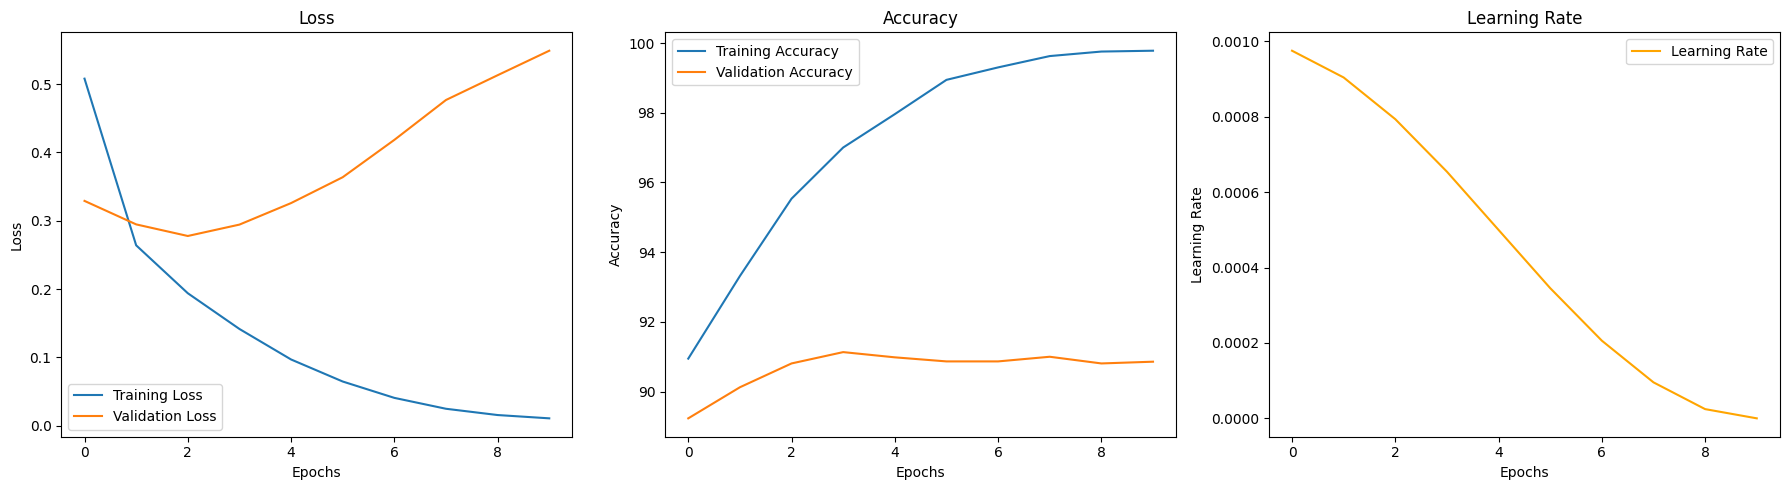

In [20]:
def plot_history(history):
    """
    Plots the training and validation loss, accuracy, and learning rate
    from a PyTorch history dictionary.

    Args:
        history (dict): Dictionary containing training metrics.
                        Expected keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc', 'lrs'.
    """
    epochs = range(len(history['train_loss']))

    plt.figure(figsize=(18, 5))

    # Plot 1: Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    # plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # plt.grid(True)

    # Plot 3: Learning Rate
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['lrs'], label='Learning Rate', color='orange')
    plt.title('Learning Rate')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.legend()
    # plt.grid(True)

    plt.tight_layout()
    plt.show()
    # plt.savefig()

plot_history(history)

---
## 4. Model Inference and Sentiment Prediction

---

In [21]:
# 1. Define the Human Labels
ag_news_labels = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

# 2. Re-use your Training Tokenizer
# This ensures "Don't" becomes ["don", "t"] consistently in both phases
tokenizer = lambda text: re.findall(r'\w+', text.lower())


# Adapted the below code from:
# https://github.com/bentrevett/pytorch-sentiment-analysis/blob/experimental/2%20-%20Upgraded%20Sentiment%20Analysis.ipynb
def predict_topic(model, sentence):
    model.eval()

    # Step A: Tokenize exactly like training
    tokens = tokenizer(sentence)

    # Step B: Numericalize using the <UNK> index (1)
    indexed = [vocab.get(t, 1) for t in tokens]

    # Step C: Prepare Tensors [Batch, Seq_Len]
    tensor = torch.LongTensor(indexed).unsqueeze(0).to(DEVICE)
    length = torch.LongTensor([len(indexed)]).to(DEVICE)

    with torch.no_grad():
        # Step D: Forward Pass
        logits = model(tensor, length)

        # Step E: Get the highest score
        # Using softmax to see the confidence %
        probs = torch.softmax(logits, dim=1)
        prediction_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][prediction_idx].item()

    return ag_news_labels[prediction_idx], confidence

# --- Test ----------------------------------------
headline = "The Olympic games were postponed due to global health concerns."
topic, score = predict_topic(model, headline)
print(f"Result: {topic} ({score:.2%})")

Result: Sports (99.27%)


In [22]:
# Create a list of test cases
ag_news_tests = [
    "The Federal Reserve is expected to keep interest rates steady as inflation cools.", # Business
    "The star striker scored a hat-trick in the final minutes of the world cup qualifier.", # Sports
    "Astronomers have discovered a new Earth-like planet orbiting a distant star system.", # Sci/Tech
    "Protests erupted in the capital city following the controversial election results.",    # World
    "New software update fixes critical security vulnerabilities in mobile operating systems." # Sci/Tech
]

print(f"{'Headline':<60} | {'Predicted Topic':<12} | {'Confidence'}")
print("-" * 85)

for text in ag_news_tests:
    topic, conf = predict_topic(model, text)
    print(f"{text[:58]:<60} | {topic:<12} | {conf:.2%}")

Headline                                                     | Predicted Topic | Confidence
-------------------------------------------------------------------------------------
The Federal Reserve is expected to keep interest rates ste   | Business     | 99.97%
The star striker scored a hat-trick in the final minutes o   | Sports       | 99.99%
Astronomers have discovered a new Earth-like planet orbiti   | Sci/Tech     | 99.98%
Protests erupted in the capital city following the controv   | World        | 99.97%
New software update fixes critical security vulnerabilitie   | Sci/Tech     | 99.99%


In [23]:
%watermark -iv

datasets   : 4.0.0
matplotlib : 3.10.0
numpy      : 2.0.2
pandas     : 2.3.3
re         : 2.2.1
sklearn    : 1.6.1
torch      : 2.9.0+cu126
torchinfo  : 1.8.0
torchvision: 0.24.0+cu126

